# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   * Dataset: Engine Fault Detection DataSource: Kaggle
   * Target: Engine_Condition (0=Normal, 1=Minor Fault, 2=Critical Fault)
   * Total Samples: 10.000
   * Features: 11 sensor readings

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
# ============================================================
# 2. IMPORT LIBRARY
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils import resample
import os
import warnings
warnings.filterwarnings('ignore')

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [5]:
df = pd.read_csv('../engine_fault_raw/engine_fault_detection_dataset.csv')

print("Shape:", df.shape)
print("\nHead:")
df.head()

Shape: (10000, 12)

Head:


,Vibration_Amplitude,RMS_Vibration,Vibration_Frequency,Surface_Temperature,Exhaust_Temperature,Acoustic_dB,Acoustic_Frequency,Intake_Pressure,Exhaust_Pressure,Frequency_Band_Energy,Amplitude_Mean,Engine_Condition
0,3.807947,1.899522,1465.396656,106.577348,319.564816,110.834195,3733.620495,91.279833,104.544934,0.889443,0.294582,0
1,9.512072,1.697915,385.333751,85.115094,237.927110,89.671023,4417.399188,114.855139,84.358093,0.916455,0.268216,0
2,7.346740,0.921962,706.346595,145.739823,250.543690,71.727937,2369.581389,97.479227,108.393914,0.440535,0.182008,0
3,6.026719,3.055970,1333.295661,56.277414,272.268451,104.198507,1516.975785,98.518121,105.296723,0.308468,0.251674,2
4,1.644585,2.409290,974.536902,100.542770,281.461334,85.120688,1662.348214,96.787358,107.565599,0.272495,0.188897,0


In [6]:
print("Info:")
df.info()

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Vibration_Amplitude    10000 non-null  float64
 1   RMS_Vibration          10000 non-null  float64
 2   Vibration_Frequency    10000 non-null  float64
 3   Surface_Temperature    10000 non-null  float64
 4   Exhaust_Temperature    10000 non-null  float64
 5   Acoustic_dB            10000 non-null  float64
 6   Acoustic_Frequency     10000 non-null  float64
 7   Intake_Pressure        10000 non-null  float64
 8   Exhaust_Pressure       10000 non-null  float64
 9   Frequency_Band_Energy  10000 non-null  float64
 10  Amplitude_Mean         10000 non-null  float64
 11  Engine_Condition       10000 non-null  int64  
dtypes: float64(11), int64(1)
memory usage: 937.6 KB


In [4]:
print("Missing values:\n", df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())
print("\nClass distribution:\n", df['Engine_Condition'].value_counts())

Missing values:
 Vibration_Amplitude      0
RMS_Vibration            0
Vibration_Frequency      0
Surface_Temperature      0
Exhaust_Temperature      0
Acoustic_dB              0
Acoustic_Frequency       0
Intake_Pressure          0
Exhaust_Pressure         0
Frequency_Band_Energy    0
Amplitude_Mean           0
Engine_Condition         0
dtype: int64

Duplicates: 0

Class distribution:
 Engine_Condition
0    5963
1    3037
2    1000
Name: count, dtype: int64


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [5]:
# 4.1 Statistik Deskriptif
df.describe()

,Vibration_Amplitude,RMS_Vibration,Vibration_Frequency,Surface_Temperature,Exhaust_Temperature,Acoustic_dB,Acoustic_Frequency,Intake_Pressure,Exhaust_Pressure,Frequency_Band_Energy,Amplitude_Mean,Engine_Condition
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992180,2.547423,1010.099781,89.845606,398.745522,90.188675,2558.761766,104.976734,95.031300,0.545828,0.255133,0.503700
std,2.847538,1.432008,567.812039,34.679351,115.713672,17.300477,1409.523813,8.579042,8.749599,0.258961,0.141254,0.670844
min,0.100115,0.050781,20.095285,30.000664,200.006695,60.000506,101.323600,90.003900,80.003865,0.100026,0.010048,0.000000
25%,2.538656,1.307032,522.420864,59.622870,297.708889,75.417389,1344.035229,97.559952,87.314803,0.320392,0.130852,0.000000
50%,4.976033,2.554189,1014.094827,90.003629,397.486877,90.365423,2570.626283,104.976943,95.127134,0.546940,0.256507,0.000000
75%,7.426063,3.794572,1494.454231,119.653950,500.190814,105.206758,3787.099025,112.434660,102.769823,0.768050,0.377475,1.000000
max,9.997205,4.999628,1999.803934,149.974725,599.988859,119.996382,4998.480399,119.996253,109.999761,0.999978,0.499890,2.000000


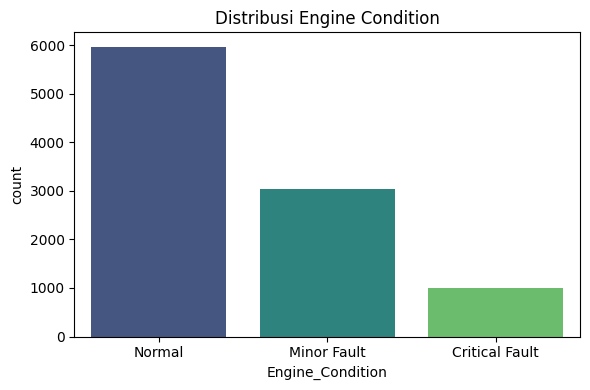

In [6]:
# 4.2 Distribusi Target
plt.figure(figsize=(6,4))
sns.countplot(x='Engine_Condition', data=df, palette='viridis')
plt.title('Distribusi Engine Condition')
plt.xticks([0,1,2], ['Normal','Minor Fault','Critical Fault'])
plt.tight_layout()
plt.savefig('class_distribution.png')
plt.show()

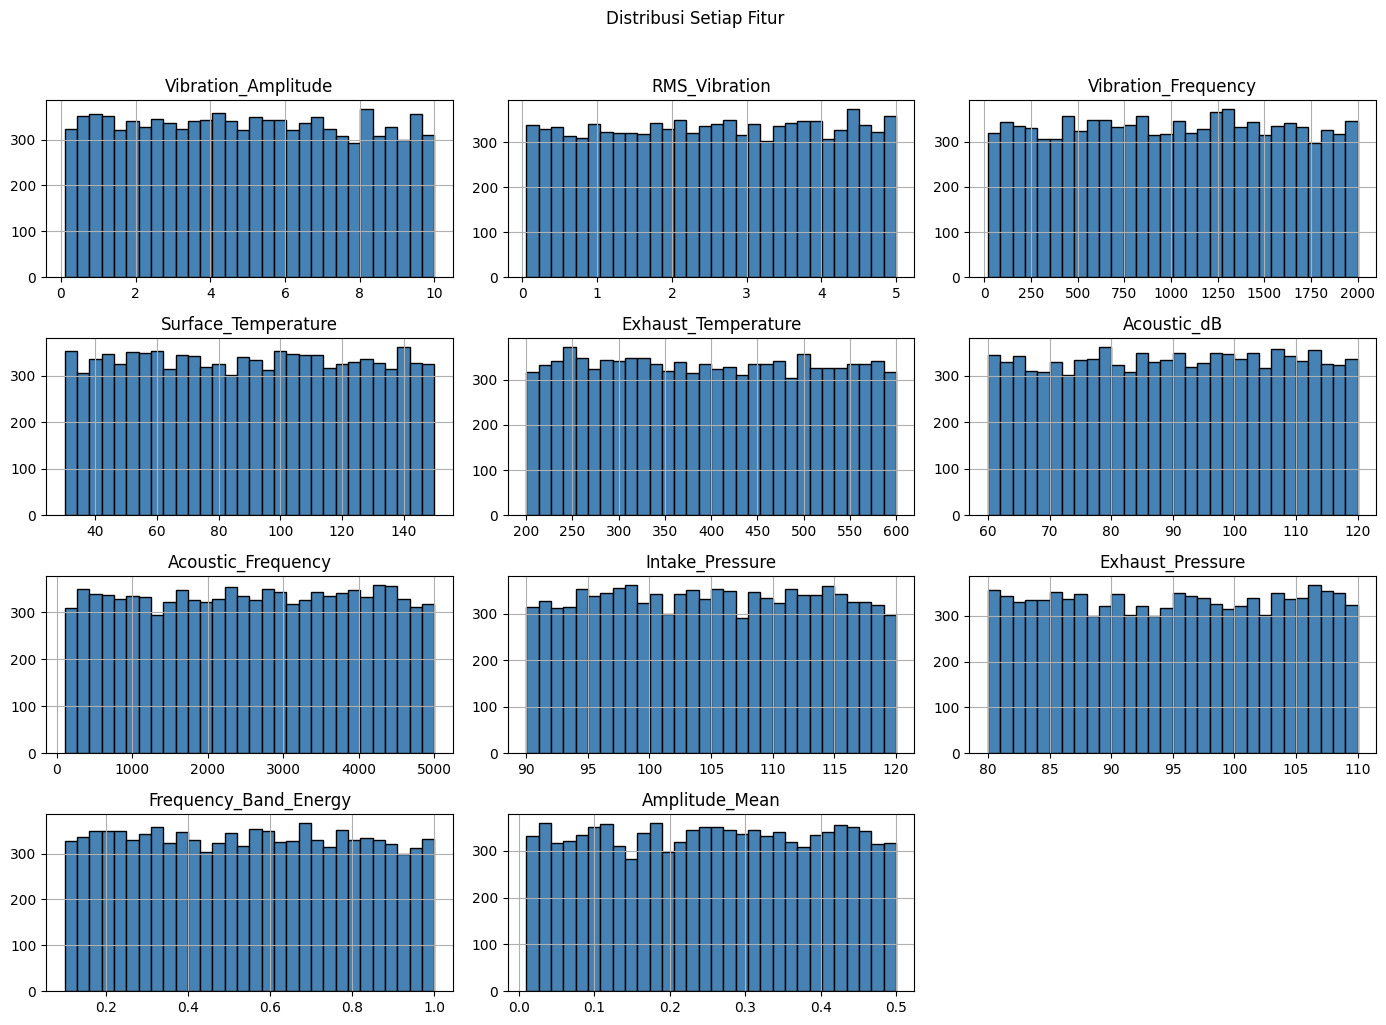

In [7]:
# 4.3 Distribusi Fitur
df.drop('Engine_Condition', axis=1).hist(figsize=(14,10), bins=30, color='steelblue', edgecolor='black')
plt.suptitle('Distribusi Setiap Fitur', y=1.02)
plt.tight_layout()
plt.savefig('feature_distributions.png')
plt.show()

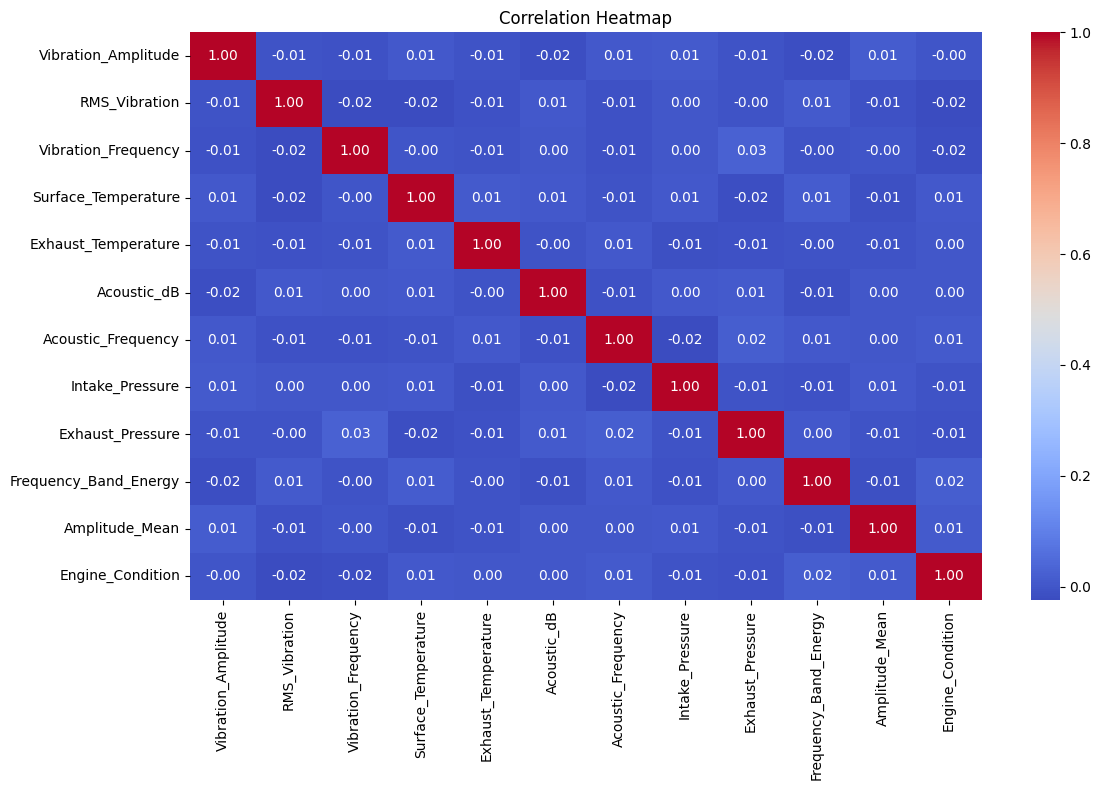

In [8]:
# 4.4 Correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('correlation_heatmap.png')
plt.show()

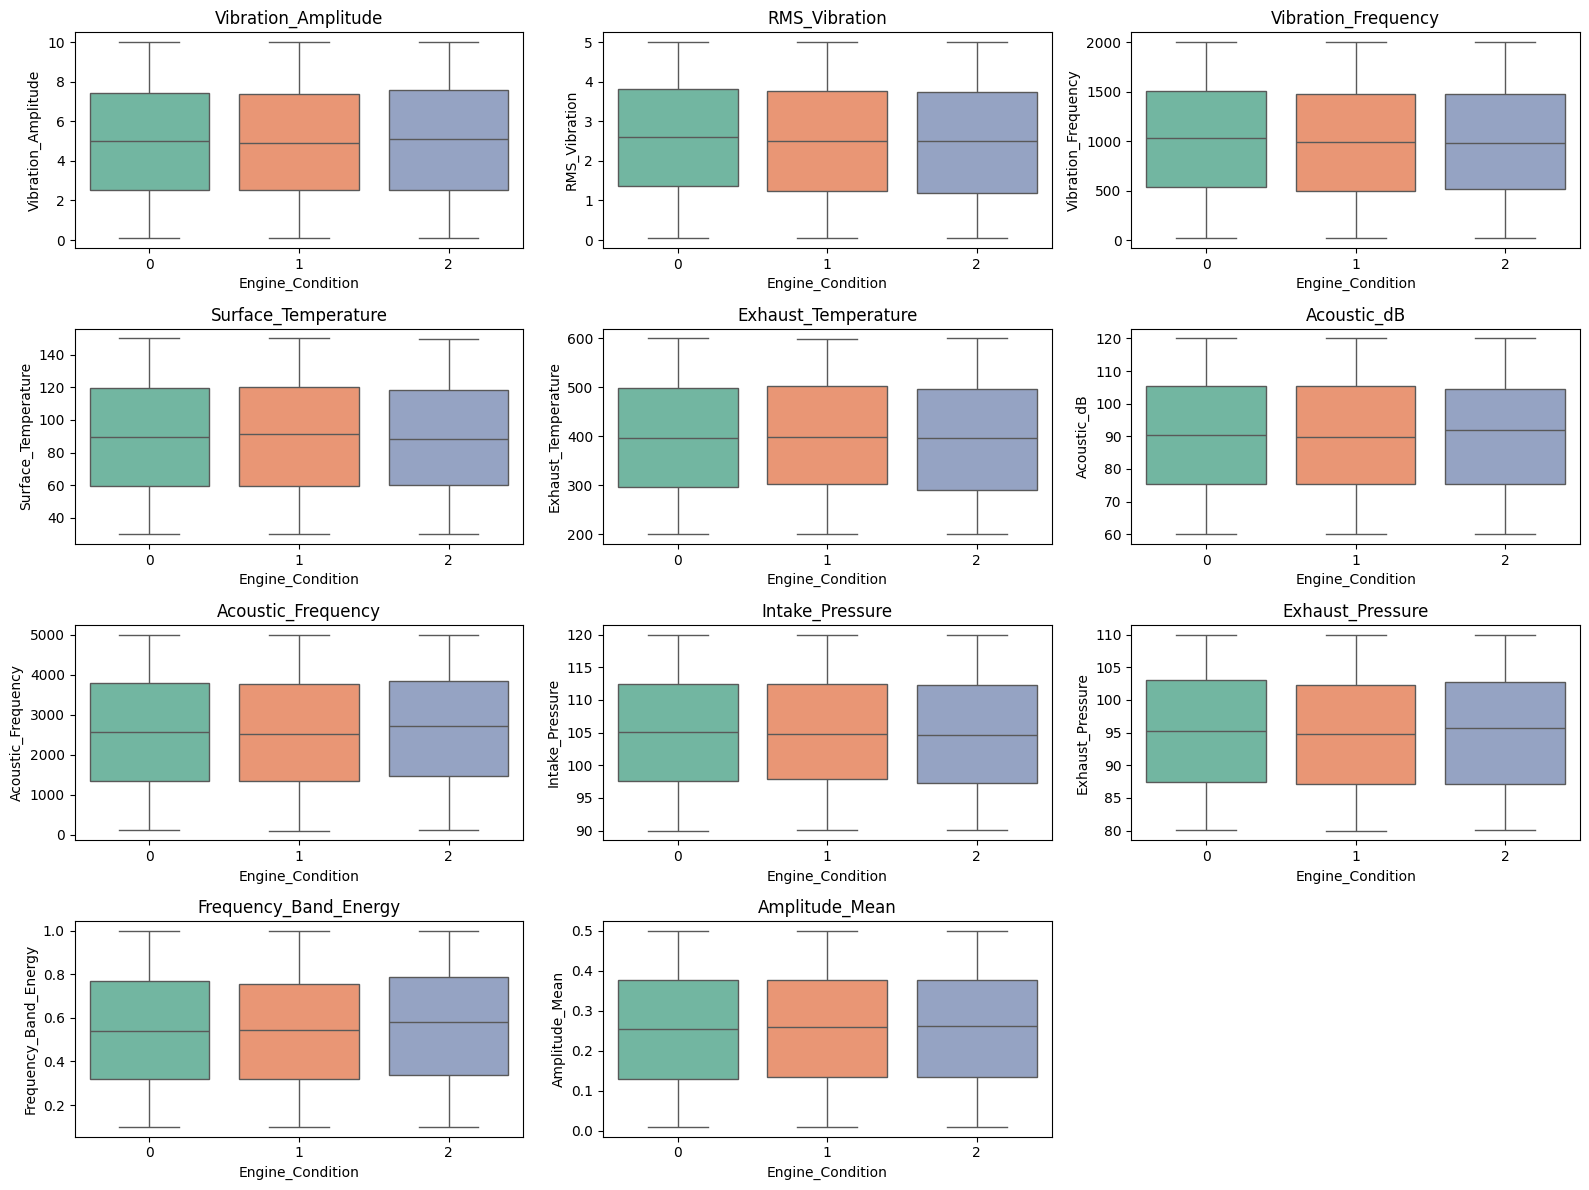

In [9]:
# 4.5 Boxplot per kelas
features = df.columns.drop('Engine_Condition')
fig, axes = plt.subplots(4, 3, figsize=(16, 12))
axes = axes.flatten()
for i, col in enumerate(features):
    sns.boxplot(x='Engine_Condition', y=col, data=df, ax=axes[i], palette='Set2')
    axes[i].set_title(col)
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.savefig('boxplot_per_class.png')
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [10]:
# 5.1 Hapus duplikat
df = df.drop_duplicates()
print("Shape setelah drop duplicate:", df.shape)

Shape setelah drop duplicate: (10000, 12)


In [11]:
# 5.2 Handle Missing Values
df = df.dropna()
print("Shape setelah dropna:", df.shape)

Shape setelah dropna: (10000, 12)


In [12]:
# 5.3 Deteksi & Handle Outlier (IQR method) - hanya fitur numerik
def remove_outliers_iqr(data, columns):
    df_clean = data.copy()
    for col in columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]
    return df_clean

feature_cols = df.columns.drop('Engine_Condition').tolist()
df = remove_outliers_iqr(df, feature_cols)
print("Shape setelah remove outlier:", df.shape)

Shape setelah remove outlier: (10000, 12)


In [13]:
# 5.4 Pisah Fitur & Target
X = df.drop('Engine_Condition', axis=1)
y = df['Engine_Condition']

In [14]:
# 5.5 Normalisasi dengan StandardScaler
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

In [15]:
# 5.6 Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (8000, 11)
X_test: (2000, 11)


In [17]:
# 5.7 Simpan hasil preprocessing
os.makedirs('/content/preprocessing/engine_fault_preprocessing', exist_ok=True)

train_df = X_train.copy()
train_df['Engine_Condition'] = y_train.values
test_df = X_test.copy()
test_df['Engine_Condition'] = y_test.values

train_df.to_csv('/content/preprocessing/engine_fault_preprocessing/train.csv', index=False)
test_df.to_csv('/content/preprocessing/engine_fault_preprocessing/test.csv', index=False)

print("Preprocessing selesai. File disimpan.")

Preprocessing selesai. File disimpan.
